# Flux Budgets (inflow / outflow)

[`fluxbudget`](@ref) measures the **flux of mass, momentum, energy and metals through a surface**
(a sphere at radius R, or a cylinder wall), with the surface-normal velocity split into separate
**inflow** and **outflow** rates — the thin-shell estimator that galactic-feedback and gas-cycle
studies otherwise hand-roll for every paper, here as a first-class, conservation-aware primitive.

The estimator is the standard shell sum: for a thin shell of width `Δr` straddling the surface at
radius R, the flux of a carried quantity `q` is `Φ = Σᵢ qᵢ·v⊥ᵢ / Δr`, with cells split by the sign of
the surface-normal velocity `v⊥` (`:vr_sphere` for a sphere, `:vr_cylinder` for a cylinder). For a thin
shell this approximates the surface integral `∮ q·v⊥ dA`. Everything is computed from `getvar` (with
correct per-level AMR cell volumes) and returned in physical rate units.

In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera
info = getinfo(300, joinpath(MERA_EXAMPLES, "RAMSES/mw_L10"))
gas  = gethydro(info, verbose=false);


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0

[Mera]: 2026-08-03T11:42:41.099



Code: RAMSES


output [300] summary:
mtime: 2023-04-09T05:34:09
ctime: 2025-06-21T18:31:24.020
simulation time: 445.89 [Myr]
boxlen: 48.0 [kpc]
ncpu: 640
ndim: 3
cosmological:  false
-------------------------------------------------------
amr:           true
level(s): 6 - 10 --> cellsize(s): 750.0 [pc] - 46.88 [pc]
-------------------------------------------------------
hydro:         true
hydro-variables:  

7  --> (:rho, :vx, :vy, :vz, :p, :scalar_00, :scalar_01)
hydro-descriptor: (:density, :velocity_x, :velocity_y, :velocity_z, :pressure, :scalar_00, :scalar_01)
γ: 1.6667
-------------------------------------------------------
gravity:       true
gravity-variables: (:epot, :ax, :ay, :az)
-------------------------------------------------------
particles:     true
- Nstars:   5.445150e+05 
particle-variables: 

...

Processing files:  98%|█████████████████████████████████████████████████▏|  ETA: 0:00:00 (29.31 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▌|  ETA: 0:00:00 (29.35 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▊|  ETA: 0:00:00 (29.45 ms/it)

Processing files: 100%|██████████████████████████████████████████████████| Time: 0:00:18 (29.41 ms/it)



✓ File processing complete! Combining results...


## Basic use

In [2]:
fb = fluxbudget(gas; surface=:sphere, radius=30.0, shell_width=2.0, range_unit=:kpc,
                quantities=[:mass, :momentum, :energy])
println("mass outflow  [Msol/yr] : ", fb.rates.mass.out)
println("mass inflow   [Msol/yr] : ", fb.rates.mass.in)
println("mass net      [Msol/yr] : ", fb.rates.mass.net)
println("energy net    [erg/s]   : ", fb.rates.energy.net)

FluxBudgetType [sphere @ R=30.0 kpc, Δr=2.0]  (cell size 0.75)


  19712 shell cells, mass 209400.0 Msol
  mass     : in -8.301e-6  out 0.004031  net 0.004023 ± 1.9e-5  [Msol_yr]
  momentum : in 8.774e-5  out 0.1754  net 0.1755 ± 0.0012  [Msol_km_s_yr]
  energy   : in -1.755e34  out 1.3009999999999998e37  net 1.2989999999999998e37 ± 8.6e34  [erg_s]
mass outflow  [Msol/yr] : 0.0040312084962625125
mass inflow   [Msol/yr] : -8.30065486215337e-6
mass net      [Msol/yr] : 0.004022907841400359
energy net    [erg/s]   : 1.2991643114304465e37


Units per quantity: **mass** and **metals** in `Msol/yr`, **momentum** in `Msol·km/s/yr`, **energy** in
`erg/s`. `in` sums cells moving inward (`v⊥ < 0`), `out` those moving outward; `net = in + out`. For
mass/metals/energy `in ≤ 0` and `out ≥ 0`; for **momentum** the carried quantity already contains `v⊥`
(radial momentum), so both `in` and `out` are ≥ 0 — the ram-pressure flux from in- and out-moving gas.

!!! note "`:metals` needs a `:metallicity` column"
    The `:metals` flux multiplies cell mass by the gas metallicity, read from a column literally named
    `:metallicity`. Mera names hydro columns from the `hydro_file_descriptor.txt`, so a `:metallicity`
    column appears only when the descriptor labels a field `metallicity`; a generically named scalar
    (e.g. `:scalar_00`) or a positional `:var6` is **not** treated as metallicity. On a run without a
    `:metallicity` column `:metals` raises a clear error rather than silently returning zero — alias
    your metal scalar to `:metallicity` before the call if needed. Likewise `:energy` needs the thermal
    energy (pressure `:p`) and errors clearly on an isothermal/pressureless output.

!!! warning "Cosmological runs: no Hubble flow"
    `v⊥` is the **peculiar** gas velocity; the Hubble flow `H(a)·r` is not added. At large radius the
    Hubble term can dominate and even flip the inflow/outflow sign, so the in/out split near turnaround
    is unreliable on cosmological/zoom runs (a `@warn` fires). The non-cosmological case is unaffected.

Use `surface=:cylinder` for the flux through a cylindrical wall (e.g. the edge of a disk):

```julia
fc = fluxbudget(gas; surface=:cylinder, radius=15.0, shell_width=1.0, range_unit=:kpc)
```

## Choosing the shell width

The estimator assumes the shell is **filled** by cells (`Σm ≈ ρ·4πR²·Δr`), so `shell_width` must be
**at least the local cell size** — ideally a few cells. A shell *thinner than the AMR* is unphysical:
it still grabs whole cells (larger than the band) but divides by the too-small `Δr`, **over-counting**
the flux. `fluxbudget` records the shell's median `cell_size` and warns when `shell_width < cell_size`;
the result's `show` flags it `UNDER-RESOLVED`. Pick `Δr ≳ ` the local cell size (use
`getvar(fluxshell(...), :cellsize, :kpc)` to check) and confirm the rate is insensitive to a modest
change in `Δr`.

## How the flux is computed (a total, not a mean)

A rate is an **integrated total over the surface**, not an average of cell values. For every cell `i`
in the thin shell, the carried quantity `qᵢ` is multiplied by its surface-normal velocity `v⊥,ᵢ`, and
these are **summed** and divided by the shell width:

```text
flux  =  ( Σᵢ qᵢ · v⊥,ᵢ ) / Δr        # a sum over shell cells, then ÷ shell width
in    =  Σ over cells with v⊥ < 0       out = Σ over cells with v⊥ ≥ 0       net = in + out
```

This is the discrete form of the surface integral `∮ q v⊥ dA`: summing the cell contributions over the
shell *volume* and dividing by its thickness `Δr` recovers the *area* integral. So `Δr` is the
**integration thickness, not a smoothing scale** — the result is (by construction) ≈ independent of `Δr`
once `Δr ≳` a cell size; a wider shell just averages over more cells and so **lowers the sampling
error**, at the cost of radial localization. The carried quantity per cell is

| `quantity` | carried `qᵢ` | rate unit |
|---|---|---|
| `:mass`     | cell mass `mᵢ`              | M⊙/yr |
| `:metals`   | `mᵢ · Zᵢ` (metallicity)    | M⊙/yr |
| `:momentum` | `mᵢ · v⊥,ᵢ` (radial momentum) | M⊙·km/s/yr |
| `:energy`   | `E_kin,ᵢ + E_therm,ᵢ`      | erg/s |

There is **no** built-in mean/median/percentile reduction of the budget itself — it is a sum, because a
flux *is* a total. The statistics live in three companions:

* **uncertainty of the total** — every rate carries `err_in`/`err_out`/`err_net`, the **sampling
  standard error of the cell-sum** (large when a few cells dominate); `bootstrap=N` adds percentile
  **confidence intervals** `ci_*` (see below).
* **angular breakdown** — [`fluxmap`](@ref) bins the shell by surface coordinate: `quantity=:vr` is the
  **mass-weighted mean** `v⊥` per (φ, cosθ/z) bin (km/s), while `quantity=:mdot` is the **per-bin sum**
  of the mass flux (M⊙/yr), whose total equals the budget's net.
* **per-cell distribution** — [`fluxshell`](@ref) returns the shell cells themselves, so you can take
  any statistic you like (`mean`/`median`/`std`/quantiles of `getvar(sh, :vr_sphere, :km_s)`, a phase
  diagram, …).

## Phase decomposition

Pass `phases` — a `NamedTuple` of shell→mask functions — for a per-phase breakdown in `.components`.
The phases sum exactly to the total (per quantity and per direction), so a paper can define its phases
once and trust the budget closes:

In [3]:
fbp = fluxbudget(gas; surface=:sphere, radius=30.0, shell_width=2.0, range_unit=:kpc,
                phases = (cold = s -> getvar(s,:T,:K) .< 1e4,
                          hot  = s -> getvar(s,:T,:K) .>= 1e4))
println("cold outflow [Msol/yr] : ", fbp.components.cold.mass.out)
println("hot  outflow [Msol/yr] : ", fbp.components.hot.mass.out)
println("cold+hot              : ", fbp.components.cold.mass.out + fbp.components.hot.mass.out)
println("total (fb.rates)      : ", fbp.rates.mass.out)

FluxBudgetType [sphere @ R=30.0 kpc, Δr=2.0]  (cell size 0.75)


  19712 shell cells, mass 209400.0 Msol
  mass     : in -8.301e-6  out 0.004031  net 0.004023 ± 1.9e-5  [Msol_yr]
  phases: [:cold, :hot]
cold outflow [Msol/yr] : 0.0
hot  outflow [Msol/yr] : 0.0040312084962625125
cold+hot              : 0.0040312084962625125
total (fb.rates)      : 0.0040312084962625125


## Derived diagnostics: mass loading, phase velocities, weighting

The raw rates combine into the diagnostics outflow studies actually quote:

**Mass-loading factor** `η = Ṁ_out / SFR` — pair `fluxbudget` with [`sfr_snapshot`](@ref):

```julia
fb  = fluxbudget(gas; surface=:sphere, radius=10.0, shell_width=2.0, range_unit=:kpc)
sfr = sfr_snapshot(getparticles(info)).sfr[1]      # current SFR [M⊙/yr]
η   = fb.rates.mass.out / sfr                       # mass loading of the outflow (inflow: use .in)
```

**Phase outflow velocities** — with `phases`, the **mass-flux-weighted normal velocity** of each phase
is `momentum.out / mass.out` (`Msol·km/s/yr ÷ Msol/yr = km/s`), because momentum carries an extra `v⊥`:

```julia
fb = fluxbudget(gas; surface=:sphere, radius=10.0, shell_width=2.0, range_unit=:kpc,
                quantities=[:mass, :momentum],
                phases=(cold=s->getvar(s,:T,:K).<1e4, hot=s->getvar(s,:T,:K).>=1e4))
η_hot    = fb.components.hot.mass.out / sfr                          # per-phase loading
v_hot    = fb.components.hot.momentum.out / fb.components.hot.mass.out   # flux-weighted v_out [km/s]
```

This cleanly separates the multiphase wind — a slow, heavy cold fountain from a fast, light hot wind:

![Phase-split outflow from a `fluxbudget` with `phases=(cold,hot)`. *Left:* the cold gas carries most of
the outflowing mass; *right:* but the hot phase leaves several times faster (flux-weighted
`v_out = ṗ_out/Ṁ_out`) — the classic slow-fountain / fast-wind split.](assets/features/flux_phases.png)

**Other weightings & statistics.** The budget is *mass-flux weighted* by construction (a flux is
`Σ q·v⊥`), and `fluxmap(:vr)` gives the **mass-weighted mean** `v⊥` per sky bin. For a **volume-weighted**
(or median, percentile, dispersion …) velocity, take the cells from [`fluxshell`](@ref) and reduce them
yourself — these can differ a lot, so pick the one your science needs:

```julia
sh = fluxshell(gas; surface=:sphere, radius=10.0, shell_width=2.0, range_unit=:kpc)
vr = getvar(sh, :vr_sphere, :km_s); m = getvar(sh, :mass, :Msol); V = getvar(sh, :volume, :kpc3)
out = vr .> 0
massw = sum(m[out].*vr[out]) / sum(m[out])          # mass-weighted mean outflow speed
volw  = sum(V[out].*vr[out]) / sum(V[out])          # volume-weighted (filling-factor) speed
using Statistics; med = median(vr[out]); p90 = quantile(vr[out], 0.9)
```

## Off-axis surfaces (tilted cylinder, plane)

`fluxbudget` is a 3-D measurement, so the surface can be tilted. A **sphere** is orientation-free. A
**cylinder** can be aligned to an arbitrary `axis` — a 3-vector, or `:angmom` (the gas net angular
momentum `L = Σ m·h`, e.g. a galaxy's spin) — and a **`:plane`** surface measures the flux crossing a
plane normal to `axis` (disk in-/outflow):

!!! note "What `radius`/`shell_width` mean per surface"
    `radius` is the **location of the surface** and `shell_width` its thickness, but "location" depends
    on the geometry: for `:sphere` it is the spherical radius `R` (shell `|r|∈[R±Δr/2]`); for `:cylinder`
    the cylindrical radius (wall at `R_cyl∈[R±Δr/2]`); and for **`:plane` it is the signed along-axis
    offset** — the plane sits at `axis·r = R` (slab `∈[R±Δr/2]`), so `radius=5, axis=[0,0,1]` is a plane
    5 kpc *above* the midplane (use a negative `radius` for below, `radius=0` for the midplane). In each
    case `v⊥` is the velocity component along the surface normal (radial for sphere/cylinder, along
    `axis` for the plane).

```julia
# disk-edge flux in the angular-momentum frame
fb = fluxbudget(gas; surface=:cylinder, radius=15.0, shell_width=2.0, range_unit=:kpc, axis=:angmom)
# fountain/wind crossing a plane 5 kpc above the disk
fb = fluxbudget(gas; surface=:plane, radius=5.0, shell_width=2.0, range_unit=:kpc, axis=[0.,0.,1.])
```

The four surface choices, made concrete — each panel is the set of cells that `fluxbudget` integrates
over for that geometry, shown edge-on over the same disk galaxy (use [`fluxshell`](@ref) to extract and
visualize any of them):

![fluxbudget surface geometries (edge-on). *Sphere:* a spherical shell at radius R (its edge-on
projection fills a disk of radius R). *Cylinder:* the vertical wall at cylindrical radius R — the
disk-edge surface. *Plane:* a slab normal to the axis at along-axis position R (here R = 10 kpc above
the midplane) — for measuring a wind/fountain crossing a height. *Off-axis cylinder:* the same wall
tilted to an arbitrary `axis` (here `[0.5,0,1]`; use `axis=:angmom` to align with the disk
spin).](assets/features/flux_geometries.png)

Off-axis selection is **cell-centre based** (vs the axis-aligned path's cell-volume intersection), so it
differs by ~10–15 % for thin shells — prefer `shell_width` ≥ a couple of cells. A cylinder's vertical
extent defaults to `2·rout`; override with `height`.

## Bootstrap confidence intervals

Beyond the analytic standard error, pass `bootstrap=N` to attach **percentile confidence intervals**
(resampling the shell cells with replacement; reproducible via `bootstrap_seed`, level set by
`ci_level`, default 0.95):

```julia
fb = fluxbudget(gas; surface=:sphere, radius=30.0, shell_width=2.0, range_unit=:kpc, bootstrap=1000)
fb.rates.mass.net, fb.rates.mass.ci_net      # e.g. 0.03, (-1.94, 1.86) → consistent with balance
```

Each rate gains `ci_in`/`ci_out`/`ci_net` `(lo, hi)` (≈ NaN without bootstrap).

## Visualizing the shell

[`fluxshell`](@ref) returns the **exact thin shell** that `fluxbudget` measured, as an ordinary
`HydroDataType` — so you can *see what was measured*. Project it (it appears as a ring/annulus), or
map the surface-normal velocity to see *where* on the shell gas flows in (`< 0`) versus out (`> 0`):

In [4]:
sh = fluxshell(gas; surface=:sphere, radius=30.0, shell_width=2.0, range_unit=:kpc)
println("shell cells           : ", length(sh.data))

fp = fluxprofile(gas; surface=:sphere, radii=5:5:50, shell_width=2.0, range_unit=:kpc)
println("radii [kpc]           : ", collect(fp.radius))
println("net Mdot(R) [Msol/yr] : ", round.(fp.net, digits=3))

shell cells           : 19712


fluxprofile [sphere, mass]: 10 shells over R=5.0–50.0 kpc, Δr=2.0


radii [kpc]           : 

[5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0]
net Mdot(R) [Msol/yr] : [-0.892, 0.55, 0.009, -0.01, -0.006, 0.004, 0.001, 0.0, 0.0, 0.0]


![`fluxshell` makes the measured surface explicit. *Left:* the full gas of a disk galaxy, edge-on.
*Right:* the cells `fluxbudget` actually integrates over — the R = 10 kpc spherical shell (its edge-on
projection is a disk of radius 10 kpc, brightest where the shell cuts the dense midplane). The budget is
the flux of gas crossing exactly this surface.](assets/features/fluxshell.png)

`fluxshell` and `fluxbudget` use the identical selection, so the visualization is guaranteed to show
exactly the cells that entered the budget. `fluxshell` and `fluxmap` accept the same `axis`/`:angmom`
and `surface=:plane` options as `fluxbudget`, so off-axis surfaces can be visualized too (the tilted
`fluxmap` unrolls the cylinder about `n̂` as a (φ′, z′) map, and its `:mdot` map still sums to the
tilted budget).

### The surface map (`fluxmap`)

`projection` of the shell flattens it onto a Cartesian plane and **superposes** the near and far side.
For the true "where on the surface does gas flow in vs out" picture, [`fluxmap`](@ref) bins the shell
by **surface coordinates** — (φ, cosθ) for a sphere (an equal-solid-angle sky map), (φ, z) for a
cylinder (the wall unrolled) — so each cell sits at its own location, no superposition:

FluxMapType [sphere @ R=30.0, Δr=2.0]  quantity=vr [km_s]


  (72, 36) grid  (φ_deg × cosθ)


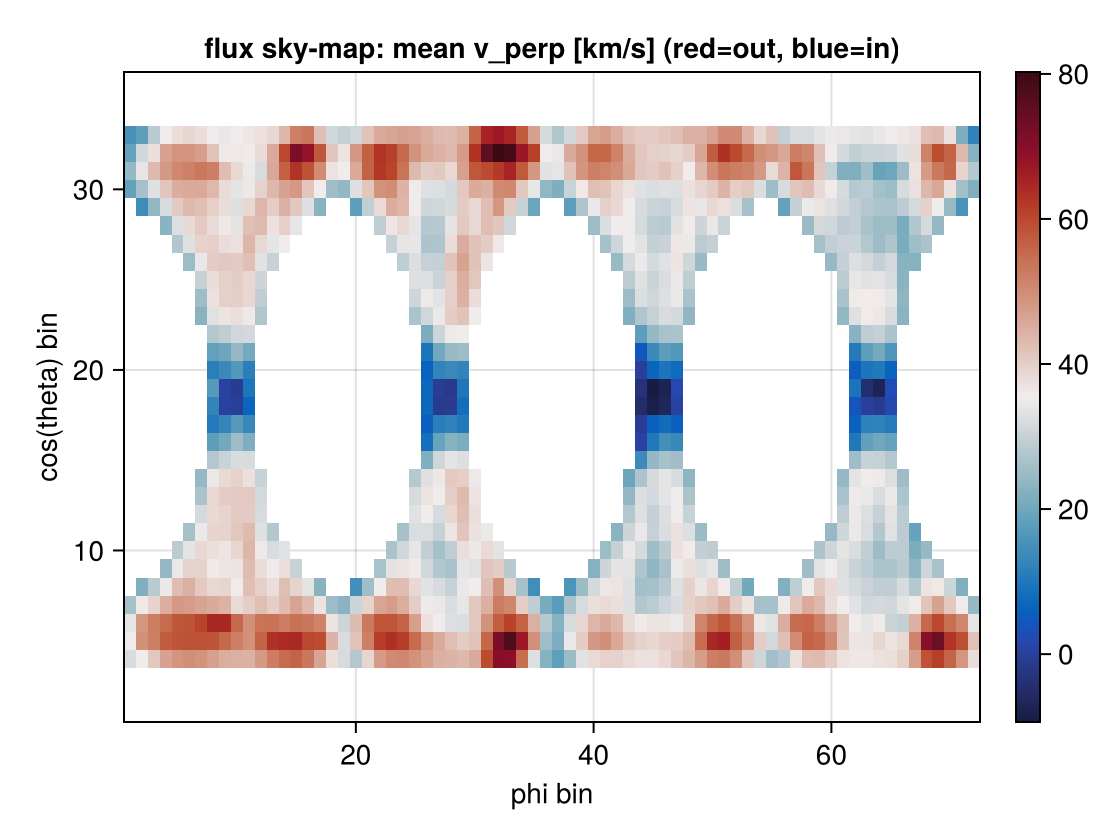

In [5]:
using CairoMakie
fm = fluxmap(gas; surface=:sphere, radius=30.0, shell_width=2.0, range_unit=:kpc, quantity=:vr)
fig = Figure(size=(560,420))
ax = Axis(fig[1,1], title="flux sky-map: mean v_perp [km/s] (red=out, blue=in)",
          xlabel="phi bin", ylabel="cos(theta) bin")
hm = heatmap!(ax, fm.map; colormap=:balance); Colorbar(fig[1,2], hm)
fig

`quantity=:vr` maps the mass-weighted mean normal velocity (inflow < 0, outflow > 0); `quantity=:mdot`
maps each bin's mass-flux contribution (Msol/yr), and its sum equals the net flux. `fluxmap` returns the
arrays; it is *not* `projection` — different axes, no LOS superposition.

![Inflow/outflow surface map of a spherical shell at R = 10 kpc around a disk galaxy (`fluxmap`,
`quantity=:vr`): the mass-weighted mean radial velocity over the (φ, cos θ) sky — blue is inflow,
red-brown is outflow. The patchy fountain (mixed in/out at every latitude) is the genuine angular
structure that a sum-into-a-single-number budget hides.](assets/features/fluxmap_skymap.png)

With a Makie backend loaded, [`fluxmapplot`](@ref) renders it directly (perceptually-uniform diverging
`:vik`, blue-in/red-out, symmetric range clipped at the `clip` percentile — default 0.95 — so a few
extreme cells don't wash out the contrast):

```julia
using CairoMakie
fig = fluxmapplot(fluxmap(gas; surface=:sphere, radius=30.0, shell_width=2.0, range_unit=:kpc))
Makie.save("flux_skymap.png", fig)
```

## Statistics: uncertainty and the radial profile

Two ways to improve the statistics of a flux measurement, both built in:

**More cells per shell** — a wider `shell_width` puts more cells in the sum (the standard
statistics-vs-localization tradeoff). Note `fluxbudget` does the **cell-by-cell sum** `Σ mᵢ·v_r,i`, which
captures the density–velocity correlation exactly — *not* `⟨ρ⟩·⟨v_r⟩` over the shell, which would lose
that correlation and bias the answer.

**Sampling uncertainty** — each rate carries `err_in`/`err_out`/`err_net`: the shot-noise standard error
of the cell-sum. It is large when a few cells dominate the flux (an under-resolved or sparsely-sampled
shell), so it tells you when a number is trustworthy:

```julia
fb = fluxbudget(gas; surface=:sphere, radius=30.0, shell_width=2.0, range_unit=:kpc)
fb.rates.mass.net, fb.rates.mass.err_net      # e.g. 0.03 ± 0.96  → consistent with balance
```

**Radial flux profile** — [`fluxprofile`](@ref) runs the budget across many radii at once, so you see
*where* the flux is launched or converges and can pick a converged radius/width:

```julia
fp = fluxprofile(gas; surface=:sphere, radii=5:5:50, shell_width=2.0, range_unit=:kpc)
fp.radius, fp.net, fp.err_net      # net Ṁ(R) ± sampling error [Msol/yr]
# e.g. net < 0 in the disk (inflow) → net > 0 in the halo (outflow); a huge err flags a bad shell
```

![Radial mass-flux profile (`fluxprofile`): inflow and outflow rates and the net (with its sampling
error band) versus radius. Both are large in the churning inner galaxy and converge to a small net at
large R; the wide band at small R flags the under-sampled inner shells.](assets/features/fluxprofile.png)

For the dominant snapshot-to-snapshot noise, time-average instead (see below).

## Time evolution

[`fluxtimeseries`](@ref) maps `fluxbudget` over a snapshot series and assembles the rate versus time —
the inflow/outflow history through a fixed surface:

```julia
loadfn = o -> gethydro(getinfo(o, "/sim"), verbose=false)
fts = fluxtimeseries(loadfn, 100:10:300, :sphere; radius=30.0, shell_width=2.0, range_unit=:kpc)
fts.t, fts.out, fts.in, fts.net      # time [Myr] and the rate history [Msol/yr]
```

## Definition & correctness

The estimator is intentionally explicit and recorded on the result (`surface`, `radius`, `shell_width`,
`center`) so the methodological choice is reproducible. The thin-shell estimator is verified against the
analytic surface integral `∮ ρ v⊥ dA = 4πR²ρv⊥` (it converges as `O((Δr/R)²)`), the inflow/outflow split
and `net = in + out` are exact, and the phase decomposition sums to the total — all guarded by the test
suite, in the same spirit as Mera's projection/covering-grid conservation oracles.

## API

The functions [`fluxbudget`](@ref), [`fluxprofile`](@ref), [`fluxtimeseries`](@ref),
[`fluxshell`](@ref), [`fluxmap`](@ref), [`fluxmapplot`](@ref) and the result types
[`FluxBudgetType`](@ref) / [`FluxMapType`](@ref) are documented in the [API reference](api.md). See also
[`shellregion`](@ref) (the shell selection underneath) and [Profiles & Phase Diagrams](15_multi_Profiles_Phase.md).